## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import missingno

import sys

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")


from utils import process_greek, create_grid, remove_accents

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
GREEK_TO_EN = str.maketrans({
    "Α": "A", "Β": "V", "Γ": "G", "Δ": "D", "Ε": "E", "Ζ": "Z", "Η": "I", "Θ": "TH",
    "Ι": "I", "Κ": "K", "Λ": "L", "Μ": "M", "Ν": "N", "Ξ": "X", "Ο": "O", "Π": "P",
    "Ρ": "R", "Σ": "S", "Τ": "T", "Υ": "Y", "Φ": "F", "Χ": "CH", "Ψ": "PS", "Ω": "O",
    "α": "a", "β": "v", "γ": "g", "δ": "d", "ε": "e", "ζ": "z", "η": "i", "θ": "th",
    "ι": "i", "κ": "k", "λ": "l", "μ": "m", "ν": "n", "ξ": "x", "ο": "o", "π": "p",
    "ρ": "r", "σ": "s", "ς": "s", "τ": "t", "υ": "y", "φ": "f", "χ": "ch",
    "ψ": "ps", "ω": "o"
})

def greek_to_english(df: pd.DataFrame, column: str) -> pd.DataFrame:
    df[column] = (
        df[column]
        .astype(str)
        .str.translate(GREEK_TO_EN)
    )
    return df

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_ID = 'EL61'

In [5]:
greece_cm_gdf = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS2.shp",  encoding=enc)
greece_cm_gdf = greece_cm_gdf.loc[greece_cm_gdf['NUTS_ID'] == f'{NUTS2_ID}'].copy()

In [6]:
greece_cm_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
6,EL61,EL,Thessalia,Θεσσαλία,Greece,"MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


In [7]:
greece_cm_gdf = greece_cm_gdf.to_crs(epsg=4326)
greece_cm_gdf.drop(columns=['NUTS_NAME'], inplace=True)
greece_cm_gdf.rename(columns={'NUTS_ID': 'div2_code',
                              'CNTR_CODE': 'div0_code',
                              'NAME_LATN': 'div2_name',
                              'CNTR_NAME': 'div0_name'}, inplace=True)

greece_cm_gdf['div0_name'] = 'ellada'
greece_cm_gdf['div1_code'] = 'EL6'
greece_cm_gdf['div1_name'] = 'kentriki ellada'
greece_cm_gdf['div2_code'] = 'EL61'

greece_cm_gdf = greece_cm_gdf[['div0_code', 'div0_name',
                               'div1_code', 'div1_name',
                               'div2_code', 'div2_name',
                               'geometry']].copy()

In [8]:
greece_cm_gdf['div0_name'] = greece_cm_gdf['div0_name'].str.lower()
greece_cm_gdf['div1_name'] = greece_cm_gdf['div1_name'].str.lower()
greece_cm_gdf['div2_name'] = greece_cm_gdf['div2_name'].str.lower()

greece_cm_gdf['div0_name'] = greece_cm_gdf['div0_name'].apply(lambda x : remove_accents(x))
greece_cm_gdf['div1_name'] = greece_cm_gdf['div1_name'].apply(lambda x : remove_accents(x))
greece_cm_gdf['div2_name'] = greece_cm_gdf['div2_name'].apply(lambda x : remove_accents(x))

greece_cm_gdf.reset_index(drop=True, inplace=True)

In [9]:
greece_cm_gdf.head()

,div0_code,div0_name,div1_code,div1_name,div2_code,div2_name,geometry
0,EL,ellada,EL6,kentriki ellada,EL61,thessalia,"MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


<Axes: >

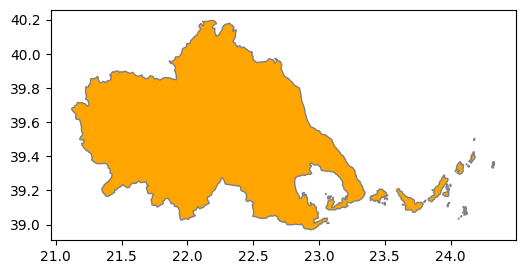

In [10]:
greece_cm_gdf.plot(facecolor="none", edgecolor='grey', figsize=(6,6), color='orange')

In [11]:
greece_cm_lv3 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS3.shp",  encoding=enc)
greece_cm_lv3 = greece_cm_lv3[greece_cm_lv3['NUTS_ID'].str.startswith(NUTS2_ID, na=False)]
greece_cm_lv3.reset_index(drop=True, inplace=True) 

In [12]:
greece_cm_lv3.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,CNTR_NAME,geometry
0,EL611,EL,"Karditsa, Trikala","Καρδίτσα, Τρίκαλα",2.0,3,3,Greece,"POLYGON ((21.91769 39.85205, 21.95557 39.84969..."
1,EL612,EL,Larisa,Λάρισα,2.0,2,1,Greece,"POLYGON ((22.66458 39.97476, 22.70870 39.95235..."
2,EL613,EL,"Magnisia, Sporades","Μαγνησία, Σποράδες",2.0,2,1,Greece,"MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


In [13]:
greece_cm_lv3 = greece_cm_lv3.to_crs(epsg=4326)
greece_cm_lv3.drop(columns=['CNTR_CODE', 'NUTS_NAME', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'CNTR_NAME'], inplace=True)

greece_cm_lv3.rename(columns={'NUTS_ID': 'div3_code',
                              'NAME_LATN': 'div3_name'}, inplace=True)

greece_cm_lv3['div3_name'] = greece_cm_lv3['div3_name'].str.lower()
greece_cm_lv3['div3_name'] = greece_cm_lv3['div3_name'].apply(lambda x : remove_accents(x))

greece_cm_lv3['div0_name'] = 'ellada'
greece_cm_lv3['div0_code'] = 'EL'
greece_cm_lv3['div1_name'] = 'kentriki ellada'
greece_cm_lv3['div1_code'] = 'EL6'
greece_cm_lv3['div2_name'] = 'thessalia'
greece_cm_lv3['div2_code'] = 'EL61'

In [14]:
greece_cm_lv3 = greece_cm_lv3[['div0_code', 'div0_name',
                               'div1_code', 'div1_name',
                               'div2_code', 'div2_name',
                               'div3_code', 'div3_name',
                               'geometry']].copy()

In [15]:
greece_cm_lv3

,div0_code,div0_name,div1_code,div1_name,div2_code,div2_name,div3_code,div3_name,geometry
0,EL,ellada,EL6,kentriki ellada,EL61,thessalia,EL611,"karditsa, trikala","POLYGON ((21.91769 39.85205, 21.95557 39.84969..."
1,EL,ellada,EL6,kentriki ellada,EL61,thessalia,EL612,larisa,"POLYGON ((22.66458 39.97476, 22.70870 39.95235..."
2,EL,ellada,EL6,kentriki ellada,EL61,thessalia,EL613,"magnisia, sporades","MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


<Axes: >

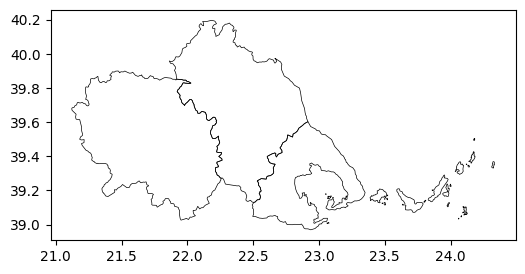

In [16]:
greece_cm_lv3.plot(facecolor="none", edgecolor='black', lw=0.5, figsize=(6,6), color='none')

In [17]:
greece_cm_lv4 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\old\el_lau1.shp",  encoding=enc)
process_greek(greece_cm_lv4, 'NAME')
greece_cm_lv4_buffered = greece_cm_lv4.copy()
greece_cm_lv4_buffered = greece_cm_lv4_buffered.to_crs("EPSG:3035") 
greece_cm_lv4_buffered["geometry"] = greece_cm_lv4_buffered.geometry.buffer(-350)

In [18]:
greece_cm_lv4_buffered = greece_cm_lv4_buffered[~greece_cm_lv4_buffered.is_empty & greece_cm_lv4_buffered.is_valid]
greece_cm_lv4.shape == greece_cm_lv4_buffered.shape

True

In [19]:
greece_cm_lv4_buffered = greece_cm_lv4_buffered.to_crs("EPSG:4326") 
cm = greece_cm_gdf.geometry.iloc[0]
greece_cm_lv4_buffered = greece_cm_lv4_buffered[greece_cm_lv4_buffered.covered_by(cm)]
greece_cm_lv4_buffered.reset_index(drop=True, inplace=True)

<Axes: >

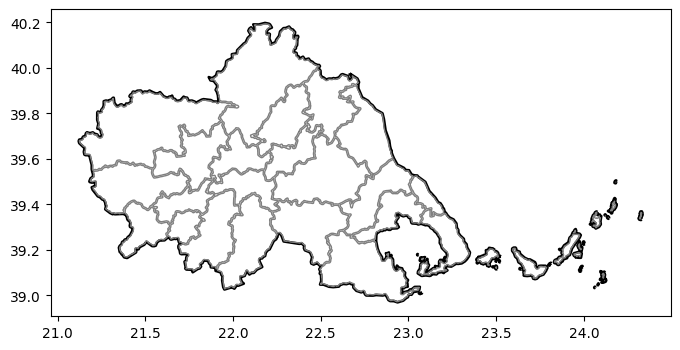

In [20]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
greece_cm_lv4_buffered.plot(facecolor="none", edgecolor='grey', ax=ax, color='none')

In [21]:
kwd_ypes = greece_cm_lv4_buffered.KWD_YPES.to_list()

In [22]:
## This addition is due to missmatching geometries after buffering

## we are manually adding the missing KWD_YPES 9229 Dimos Elefsinas

# kwd_ypes.append('9229')

In [23]:
## Renaming div4_names names based on wrong shapefile names

## kalampakas -> metewrwn

greece_cm_lv4.loc[greece_cm_lv4['NAME'] == 'καλαμπακας', 'NAME'] = 'μετεωρων'

In [24]:
greece_cm_lv4 = greece_cm_lv4[greece_cm_lv4['KWD_YPES'].isin(kwd_ypes)].copy()
greece_cm_lv4.rename(columns={'KWD_YPES': 'div4_code',
                             'NAME': 'div4_name'}, inplace=True)
greece_cm_lv4 = greek_to_english(greece_cm_lv4, "div4_name")
greece_cm_lv4.reset_index(drop=True, inplace=True)

In [25]:
greece_cm_lv4

,div4_name,div4_code,geometry
0,agias,9097,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
1,alonnisoy,9109,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
2,almyroy,9104,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
3,argitheas,9091,"POLYGON ((21.43616 39.41522, 21.43830 39.41454..."
4,voloy,9105,"POLYGON ((22.97208 39.45655, 22.97346 39.45643..."
5,elassonas,9098,"POLYGON ((22.18705 40.19547, 22.18798 40.19536..."
6,zagoras moyresioy,9106,"POLYGON ((23.05002 39.52768, 23.05012 39.52755..."
7,meteoron,9112,"POLYGON ((21.46906 39.90015, 21.46953 39.90015..."
8,karditsas,9092,"POLYGON ((21.98649 39.46579, 21.98833 39.46559..."
9,kileler,9099,"POLYGON ((22.52211 39.70151, 22.52350 39.70143..."


<Axes: >

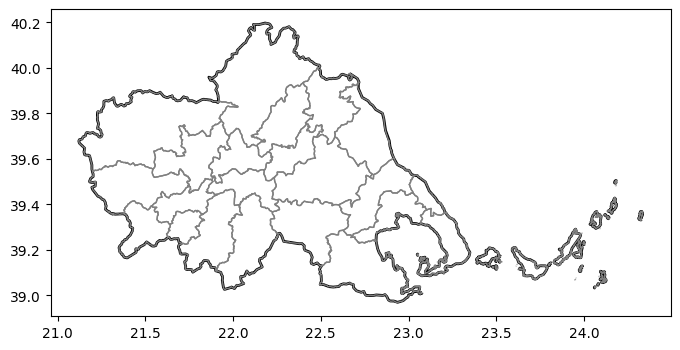

In [26]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
greece_cm_lv4.plot(facecolor="none", edgecolor='grey', ax=ax, color='none')

In [27]:
## GPT Code to enrich lv4 with lv3 attributes

# -------------------------------------------------------------------
# Inputs (already in memory):
#   greece_cm_lv3: polygons with div0..div3 + geometry
#   greece_cm_lv4: polygons with div4 + geometry
# Output:
#   greece_cm_lv4_enriched: lv4 with div0..div3 columns added
# -------------------------------------------------------------------

ADMIN_COLS = [
    "div0_code", "div0_name",
    "div1_code", "div1_name",
    "div2_code", "div2_name",
    "div3_code", "div3_name",
]

# 1) Ensure CRS is set and aligned
if greece_cm_lv3.crs is None or greece_cm_lv4.crs is None:
    raise ValueError(
        "One of the GeoDataFrames has no CRS set. "
        "Set it first with .set_crs(..., inplace=True) before running this."
    )

if greece_cm_lv3.crs != greece_cm_lv4.crs:
    greece_cm_lv4 = greece_cm_lv4.to_crs(greece_cm_lv3.crs)

# 2) Compute inside-points for lv4 (use representative_point to guarantee inside)
lv4 = greece_cm_lv4.copy()
crs_orig = lv4.crs

# For accurate point computations, do it in a metric CRS if current CRS is geographic
if crs_orig.is_geographic:
    # ETRS89 / LAEA Europe (meters) - safe default for Europe/Greece
    lv4_metric = lv4.to_crs(3035)
    lv4_metric["__pt"] = lv4_metric.geometry.representative_point()
    lv4["__pt"] = lv4_metric["__pt"].to_crs(crs_orig)
else:
    lv4["__pt"] = lv4.geometry.representative_point()

lv4_pts = gpd.GeoDataFrame(
    lv4[["div4_code", "div4_name", "__pt"]].copy(),
    geometry="__pt",
    crs=crs_orig,
)

# 3) Spatial join: which lv3 polygon contains the lv4 inside-point?
lv3_for_join = greece_cm_lv3[ADMIN_COLS + ["geometry"]].copy()

# If you suspect invalid geometries in lv3, uncomment:
# lv3_for_join["geometry"] = lv3_for_join.geometry.make_valid()

joined = (
    gpd.sjoin(
        lv4_pts,
        lv3_for_join,
        how="left",
        predicate="within",   # point within polygon
    )
    .drop(columns=["index_right"], errors="ignore")
)

# 4) Merge attributes back onto lv4 polygons
greece_cm_lv4_enriched = (
    greece_cm_lv4
    .merge(joined[["div4_code"] + ADMIN_COLS], on="div4_code", how="left")
)

# 5) Quick diagnostics
missing = greece_cm_lv4_enriched[ADMIN_COLS].isna().any(axis=1)
print(f"Unmatched LV4 rows (no containing LV3 polygon found): {missing.sum()} / {len(missing)}")


Unmatched LV4 rows (no containing LV3 polygon found): 0 / 25


In [28]:
greece_cm_lv4 = greece_cm_lv4_enriched[['div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'geometry']].copy()

In [29]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

In [30]:
df_grid_cm_d2 = create_grid(empty_gdf, greece_cm_gdf, col_municipal='div0_name', dimension=2)

In [31]:
df_grid_cm_d2.head()

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((21.16704 39.67045, 21.16704 39.68842...",POINT (21.155488402451258 39.67943231820849),ellada,21.15549,39.67943,2
1,"POLYGON ((21.19015 39.61655, 21.19015 39.63452...",POINT (21.178597337418765 39.625532243407854),ellada,21.17860,39.62553,2
2,"POLYGON ((21.19015 39.63452, 21.19015 39.65248...",POINT (21.178597337418765 39.643498935008054),ellada,21.17860,39.64350,2
3,"POLYGON ((21.19015 39.65248, 21.19015 39.67045...",POINT (21.178597337418765 39.661465626608276),ellada,21.17860,39.66147,2
4,"POLYGON ((21.19015 39.67045, 21.19015 39.68842...",POINT (21.178597337418765 39.67943231820849),ellada,21.17860,39.67943,2


In [32]:
df_grid_cm_d2.shape

(3238, 6)

<Axes: >

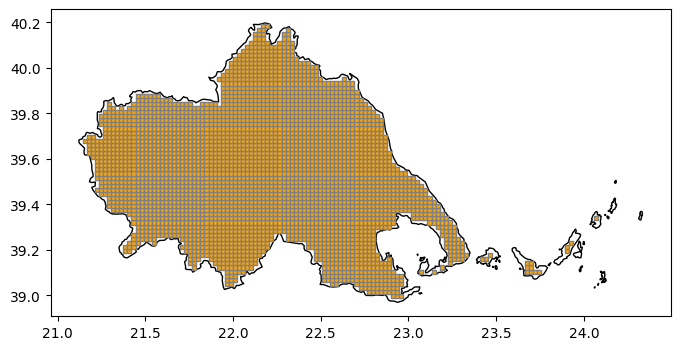

In [33]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
df_grid_cm_d2.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [34]:
df_grid_cm_d2.set_geometry('centers', inplace=True)
df_grid_cm_d2.set_crs(epsg=4326, inplace=True)

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((21.16704 39.67045, 21.16704 39.68842...",POINT (21.15549 39.67943),ellada,21.15549,39.67943,2
1,"POLYGON ((21.19015 39.61655, 21.19015 39.63452...",POINT (21.17860 39.62553),ellada,21.17860,39.62553,2
2,"POLYGON ((21.19015 39.63452, 21.19015 39.65248...",POINT (21.17860 39.64350),ellada,21.17860,39.64350,2
3,"POLYGON ((21.19015 39.65248, 21.19015 39.67045...",POINT (21.17860 39.66147),ellada,21.17860,39.66147,2
4,"POLYGON ((21.19015 39.67045, 21.19015 39.68842...",POINT (21.17860 39.67943),ellada,21.17860,39.67943,2
...,...,...,...,...,...,...
3233,"POLYGON ((23.75524 39.09551, 23.75524 39.11348...",POINT (23.74369 39.10450),ellada,23.74369,39.10450,2
3234,"POLYGON ((23.91701 39.18535, 23.91701 39.20331...",POINT (23.90545 39.19433),ellada,23.90545,39.19433,2
3235,"POLYGON ((23.91701 39.20331, 23.91701 39.22128...",POINT (23.90545 39.21230),ellada,23.90545,39.21230,2
3236,"POLYGON ((23.94012 39.22128, 23.94012 39.23925...",POINT (23.92856 39.23027),ellada,23.92856,39.23027,2


In [35]:
greece_cm_grid = gpd.sjoin(df_grid_cm_d2, greece_cm_lv4, how='left', op='within')

In [36]:
greece_cm_grid.head()

,geometry,centers,div0_name_left,x,y,resolution_km,index_right,div0_name_right,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code
0,"POLYGON ((21.16704 39.67045, 21.16704 39.68842...",POINT (21.15549 39.67943),ellada,21.15549,39.67943,2,7,ellada,kentriki ellada,thessalia,"karditsa, trikala",meteoron,EL,EL6,EL61,EL611,9112
1,"POLYGON ((21.19015 39.61655, 21.19015 39.63452...",POINT (21.17860 39.62553),ellada,21.17860,39.62553,2,7,ellada,kentriki ellada,thessalia,"karditsa, trikala",meteoron,EL,EL6,EL61,EL611,9112
2,"POLYGON ((21.19015 39.63452, 21.19015 39.65248...",POINT (21.17860 39.64350),ellada,21.17860,39.64350,2,7,ellada,kentriki ellada,thessalia,"karditsa, trikala",meteoron,EL,EL6,EL61,EL611,9112
3,"POLYGON ((21.19015 39.65248, 21.19015 39.67045...",POINT (21.17860 39.66147),ellada,21.17860,39.66147,2,7,ellada,kentriki ellada,thessalia,"karditsa, trikala",meteoron,EL,EL6,EL61,EL611,9112
4,"POLYGON ((21.19015 39.67045, 21.19015 39.68842...",POINT (21.17860 39.67943),ellada,21.17860,39.67943,2,7,ellada,kentriki ellada,thessalia,"karditsa, trikala",meteoron,EL,EL6,EL61,EL611,9112


In [37]:
greece_cm_grid.dropna(inplace=True)

In [38]:
final_grid = greece_cm_grid[['x', 'y', 'div0_name_right', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']].copy()
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'div0_name_right': "div0_name"}, inplace=True)
final_grid.sort_values(by=['x', 'y', 'div4_name'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

<Axes: >

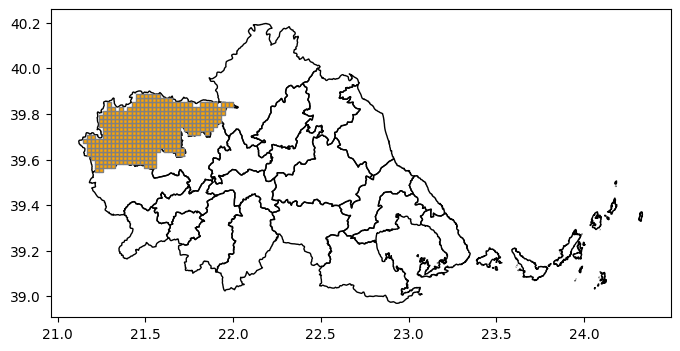

In [39]:
ax = greece_cm_lv4.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
final_grid[final_grid['div4_name'] == 'meteoron'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [40]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of greece_cm_lv4: {greece_cm_lv4.div4_name.unique().shape}')

Shape of final_grid: (25,)
Shape of greece_cm_lv4: (25,)


In [41]:
diff = list(set(greece_cm_lv4.div4_name.unique().tolist()) - set(final_grid.div4_name.unique().tolist()))
print(f'Difference is: {len(diff)}')
print(f'Missing GIDs are: {diff}') 

Difference is: 0
Missing GIDs are: []


In [42]:
missing_LAUs_d2 = greece_cm_lv4[greece_cm_lv4.div4_name.isin(diff)].copy()
missing_LAUs_d2.reset_index(drop=True, inplace=True)

In [43]:
missing_LAUs_d2

,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,geometry


In [44]:
missing_LAUs_d2["centers"] = missing_LAUs_d2.geometry.centroid

In [45]:
missing_LAUs_d2['resolution_km'] = 1

In [46]:
# ax = missing_LAUs_d2.plot(edgecolor='black', facecolor='none', figsize=(6, 6))
# missing_LAUs_d2['centers'].plot(ax=ax, color='red', markersize=5)

In [47]:
missing_LAUs_d2["x"] = missing_LAUs_d2["centers"].x
missing_LAUs_d2["y"] = missing_LAUs_d2["centers"].y
missing_LAUs_d2 = missing_LAUs_d2[['x', 'y', 'div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']]



In [48]:
missing_LAUs_d2.head()

,x,y,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,centers,geometry


In [49]:
final_grid = pd.concat([final_grid, missing_LAUs_d2], ignore_index=True)

In [50]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of greece_cm_lv4: {greece_cm_lv4.div4_name.unique().shape}')

Shape of final_grid: (25,)
Shape of greece_cm_lv4: (25,)


In [51]:
final_grid.sort_values(by=['div2_code', 'div3_code', 'div4_code', 'x', 'y'], inplace = True)
final_grid.rename(columns={'x': 'longitude', 'y': 'latitude'}, inplace=True)
final_grid.reset_index(drop=True, inplace=True)
final_grid.drop(columns=['centers'], inplace=True)
final_grid

,longitude,latitude,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,geometry
0,21.38658,39.19433,ellada,kentriki ellada,thessalia,"karditsa, trikala",argitheas,EL,EL6,EL61,EL611,9091,2,"POLYGON ((21.39813 39.18535, 21.39813 39.20331..."
1,21.38658,39.21230,ellada,kentriki ellada,thessalia,"karditsa, trikala",argitheas,EL,EL6,EL61,EL611,9091,2,"POLYGON ((21.39813 39.20331, 21.39813 39.22128..."
2,21.38658,39.37400,ellada,kentriki ellada,thessalia,"karditsa, trikala",argitheas,EL,EL6,EL61,EL611,9091,2,"POLYGON ((21.39813 39.36502, 21.39813 39.38298..."
3,21.40969,39.19433,ellada,kentriki ellada,thessalia,"karditsa, trikala",argitheas,EL,EL6,EL61,EL611,9091,2,"POLYGON ((21.42124 39.18535, 21.42124 39.20331..."
4,21.40969,39.21230,ellada,kentriki ellada,thessalia,"karditsa, trikala",argitheas,EL,EL6,EL61,EL611,9091,2,"POLYGON ((21.42124 39.20331, 21.42124 39.22128..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3233,23.69747,39.10450,ellada,kentriki ellada,thessalia,"magnisia, sporades",skopeloy,EL,EL6,EL61,EL613,9111,2,"POLYGON ((23.70903 39.09551, 23.70903 39.11348..."
3234,23.69747,39.12246,ellada,kentriki ellada,thessalia,"magnisia, sporades",skopeloy,EL,EL6,EL61,EL613,9111,2,"POLYGON ((23.70903 39.11348, 23.70903 39.13145..."
3235,23.69747,39.14043,ellada,kentriki ellada,thessalia,"magnisia, sporades",skopeloy,EL,EL6,EL61,EL613,9111,2,"POLYGON ((23.70903 39.13145, 23.70903 39.14941..."
3236,23.72058,39.10450,ellada,kentriki ellada,thessalia,"magnisia, sporades",skopeloy,EL,EL6,EL61,EL613,9111,2,"POLYGON ((23.73213 39.09551, 23.73213 39.11348..."


In [ ]:
final_grid.loc[final_grid['div3_name'] == 'magnisia, sporades', 'div3_name'] = 'magnisia sporades'
final_grid.loc[final_grid['div3_name'] == 'karditsa, trikala', 'div3_name'] = 'karditsa trikala'

string_cols = final_grid.select_dtypes(include=['object', 'string']).columns

final_grid[string_cols] = final_grid[string_cols].apply(lambda col: col.map(remove_accents))
final_grid[string_cols] = final_grid[string_cols].apply(lambda col: col.str.replace(r"[,.]", "", regex=True))

In [53]:
if final_grid['div3_code'].isnull().any():
    raise ValueError("div3_code contains NULL values, need rules to handle them.")

# Create a "counter" per div3_code
final_grid['counter'] = final_grid.groupby('div3_code').cumcount() + 1

# Convert counter to hex, padded to 5 digits
final_grid['hex_counter'] = final_grid['counter'].apply(lambda x: format(x, '05X'))

# Final point_code = div3_code + hex_counter
final_grid['point_code'] = final_grid['div3_code'] + final_grid['hex_counter']

# Drop helper columns
final_grid = final_grid.drop(columns=['counter', 'hex_counter'])

In [54]:
final_grid = final_grid[['point_code', 'latitude', 'longitude', 'div0_name', 'div0_code', 'div1_name', 'div1_code', 'div2_name', 'div2_code', 'div3_name', 'div3_code', 'div4_name','div4_code', 'resolution_km', 'geometry']].copy()

<Axes: >

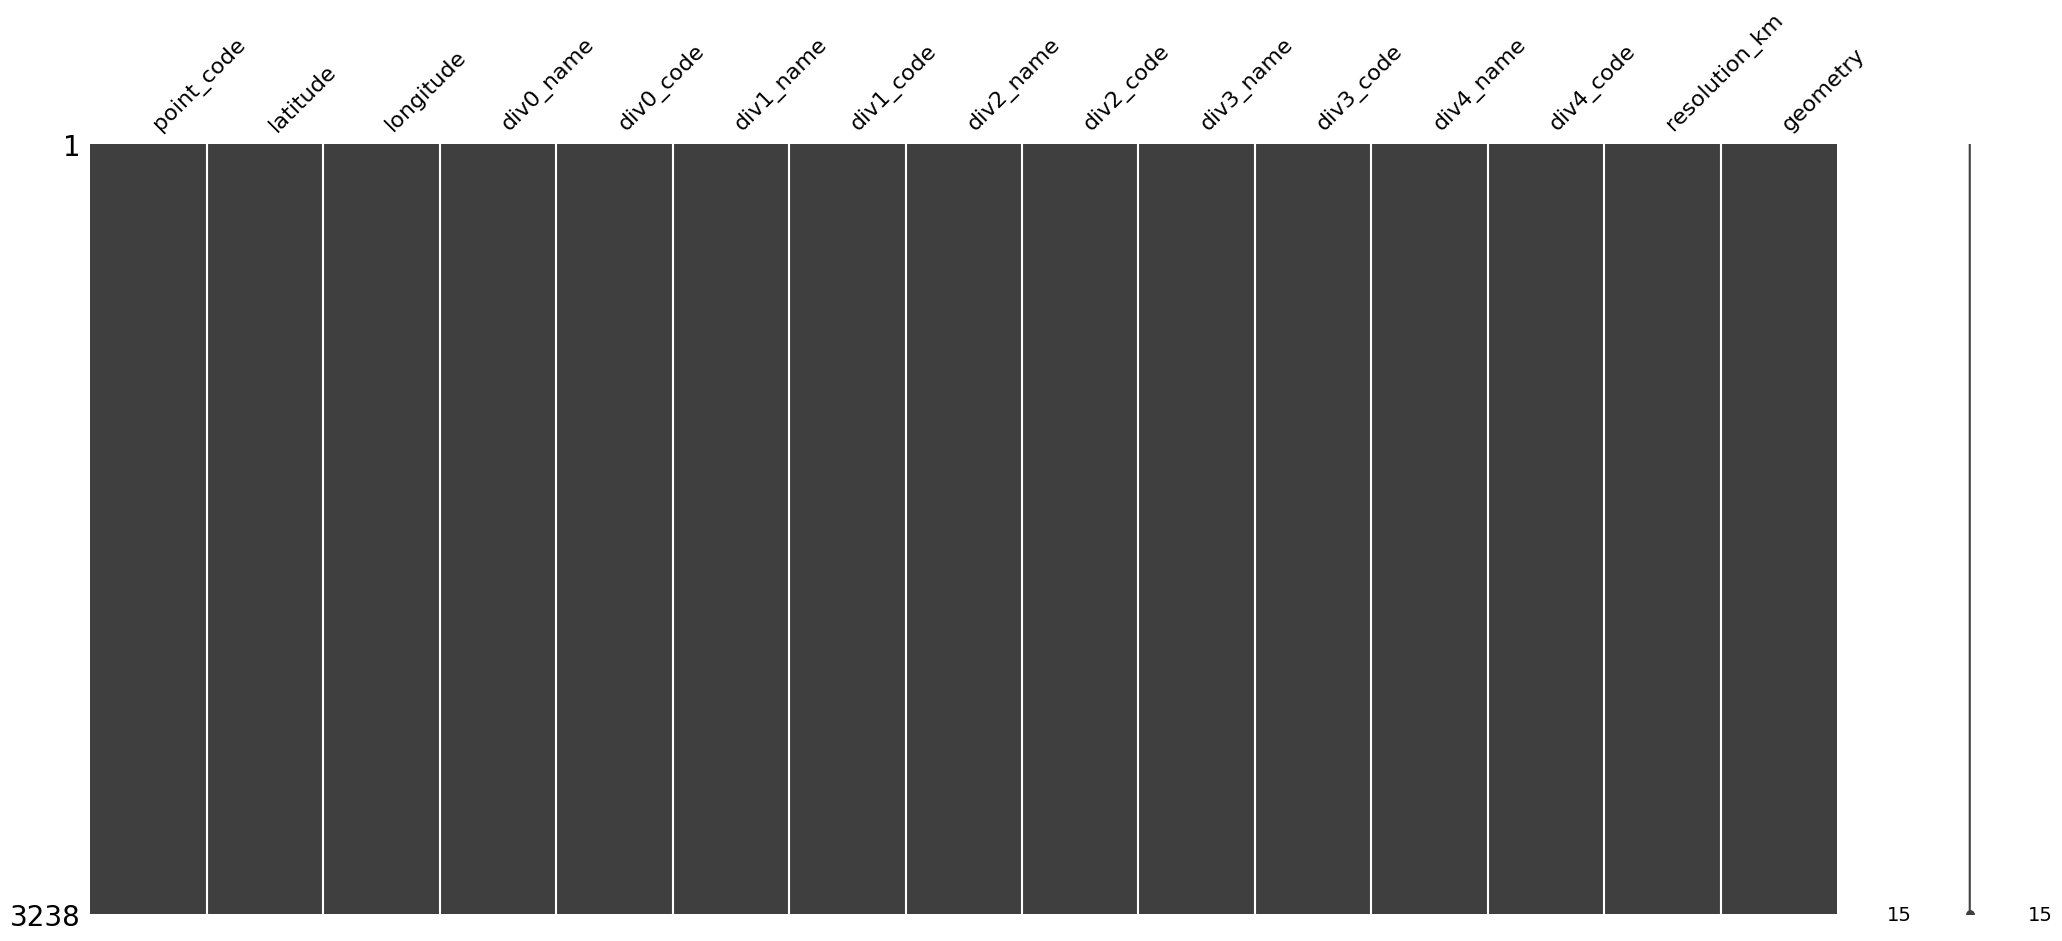

In [55]:
missingno.matrix(final_grid)

In [56]:
final_grid

,point_code,latitude,longitude,div0_name,div0_code,div1_name,div1_code,div2_name,div2_code,div3_name,div3_code,div4_name,div4_code,resolution_km,geometry
0,EL61100001,39.19433,21.38658,ellada,EL,kentriki ellada,EL6,thessalia,EL61,karditsa trikala,EL611,argitheas,9091,2,"POLYGON ((21.39813 39.18535, 21.39813 39.20331..."
1,EL61100002,39.21230,21.38658,ellada,EL,kentriki ellada,EL6,thessalia,EL61,karditsa trikala,EL611,argitheas,9091,2,"POLYGON ((21.39813 39.20331, 21.39813 39.22128..."
2,EL61100003,39.37400,21.38658,ellada,EL,kentriki ellada,EL6,thessalia,EL61,karditsa trikala,EL611,argitheas,9091,2,"POLYGON ((21.39813 39.36502, 21.39813 39.38298..."
3,EL61100004,39.19433,21.40969,ellada,EL,kentriki ellada,EL6,thessalia,EL61,karditsa trikala,EL611,argitheas,9091,2,"POLYGON ((21.42124 39.18535, 21.42124 39.20331..."
4,EL61100005,39.21230,21.40969,ellada,EL,kentriki ellada,EL6,thessalia,EL61,karditsa trikala,EL611,argitheas,9091,2,"POLYGON ((21.42124 39.20331, 21.42124 39.22128..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3233,EL61300209,39.10450,23.69747,ellada,EL,kentriki ellada,EL6,thessalia,EL61,magnisia sporades,EL613,skopeloy,9111,2,"POLYGON ((23.70903 39.09551, 23.70903 39.11348..."
3234,EL6130020A,39.12246,23.69747,ellada,EL,kentriki ellada,EL6,thessalia,EL61,magnisia sporades,EL613,skopeloy,9111,2,"POLYGON ((23.70903 39.11348, 23.70903 39.13145..."
3235,EL6130020B,39.14043,23.69747,ellada,EL,kentriki ellada,EL6,thessalia,EL61,magnisia sporades,EL613,skopeloy,9111,2,"POLYGON ((23.70903 39.13145, 23.70903 39.14941..."
3236,EL6130020C,39.10450,23.72058,ellada,EL,kentriki ellada,EL6,thessalia,EL61,magnisia sporades,EL613,skopeloy,9111,2,"POLYGON ((23.73213 39.09551, 23.73213 39.11348..."


In [57]:
final_grid.drop(columns='geometry').to_csv(f'../../data/{NUTS2}/GR_{NUTS2}_Grid_DB.csv', encoding=enc, index = False)
# final_grid.to_file(f'../data/CM_Nord_Grid.shp', encoding = 'utf-8')